In [114]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import utils as np_utils
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, GlobalMaxPooling1D, Conv1D, MaxPooling1D, Embedding, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.datasets import reuters

In [115]:
# importando os dados de treino e teste
(X_train, y_train), (X_test, y_test) = reuters.load_data()
X_train

array([list([1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 16784, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 19261, 49, 2295, 13415, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 13415, 30625, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4

In [116]:
# veriricando o mapa de indexação das palavras
word_index = reuters.get_word_index()
word_index

{'mdbl': 10996,
 'fawc': 16260,
 'degussa': 12089,
 'woods': 8803,
 'hanging': 13796,
 'localized': 20672,
 'sation': 20673,
 'chanthaburi': 20675,
 'refunding': 10997,
 'hermann': 8804,
 'passsengers': 20676,
 'stipulate': 20677,
 'heublein': 8352,
 'screaming': 20713,
 'tcby': 16261,
 'four': 185,
 'grains': 1642,
 'broiler': 20680,
 'wooden': 12090,
 'wednesday': 1220,
 'highveld': 13797,
 'duffour': 7593,
 '0053': 20681,
 'elections': 3914,
 '270': 2563,
 '271': 3551,
 '272': 5113,
 '273': 3552,
 '274': 3400,
 'rudman': 7975,
 '276': 3401,
 '277': 3478,
 '278': 3632,
 '279': 4309,
 'dormancy': 9381,
 'errors': 7247,
 'deferred': 3086,
 'sptnd': 20683,
 'cooking': 8805,
 'stratabit': 20684,
 'designing': 16262,
 'metalurgicos': 20685,
 'databank': 13798,
 '300er': 20686,
 'shocks': 20687,
 'nawg': 7972,
 'tnta': 20688,
 'perforations': 20689,
 'affiliates': 2891,
 '27p': 20690,
 'ching': 16263,
 'china': 595,
 'wagyu': 16264,
 'affiliated': 3189,
 'chino': 16265,
 'chinh': 16266,
 '

In [117]:
# inverter o dicionário para encontrar as palavras e traduzir a noticia
# criando um dicionário inverso
inverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# mostrando uma noticia
news = ' '.join([inverse_word_index.get(i-3, '?') for i in X_train[0]]) # a lógica do i-3 é por conta da forma de indexação do keras, que reserva os valores até 3 para funções específicas
news

'? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [118]:
# padding com as sequências de tokens
MAX_LEN = 500

X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)
X_train.shape, X_test.shape

((8982, 500), (2246, 500))

In [119]:
# Transformando as respostas em valores categóricos
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
y_train.shape, y_test.shape

((8982, 46), (2246, 46))

In [120]:
# Quantidade de tokens únicos
V = max(np.max(X_train), np.max(X_test))

# Tamanho das sequências de palavras
T = X_train.shape[1]

# Dimensão do Embedding
D = 64

# Quantidade de labels
L = y_train.shape[1]

V, T, D, L

(30981, 500, 64, 46)

In [121]:
# Criando a rede neural

i = Input(shape=(T,))
x = Embedding(V + 1, D)(i)
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x) 
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x) 
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(units=64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(units=64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(units=L, activation='softmax')(x)

model = Model(i, x)

In [122]:
# compilação
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [123]:
r = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.4444 - loss: 2.0711 - val_accuracy: 0.5819 - val_loss: 1.6228
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6096 - loss: 1.5088 - val_accuracy: 0.6287 - val_loss: 1.4518
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.6657 - loss: 1.2500 - val_accuracy: 0.6581 - val_loss: 1.3507
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7089 - loss: 1.0762 - val_accuracy: 0.6576 - val_loss: 1.4064
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7455 - loss: 0.9441 - val_accuracy: 0.6683 - val_loss: 1.3483
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7700 - loss: 0.8415 - val_accuracy: 0.6790 - val_loss: 1.3801
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.7895 - loss: 0.7498 - val_accuracy: 0.6879 - val_loss: 1.4589
Epoch 8/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8066 - loss: 0.6957 - 

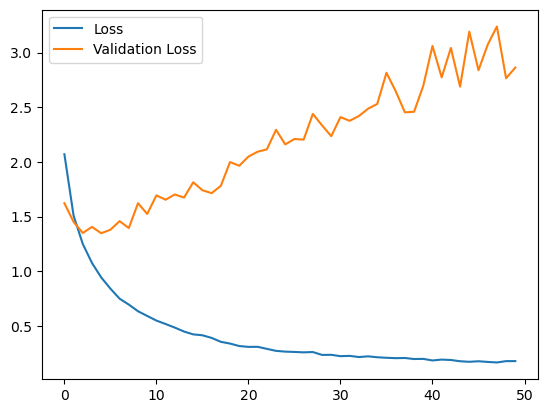

In [124]:
# comparação da perda e da validação ao longo do treinamento
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.legend()

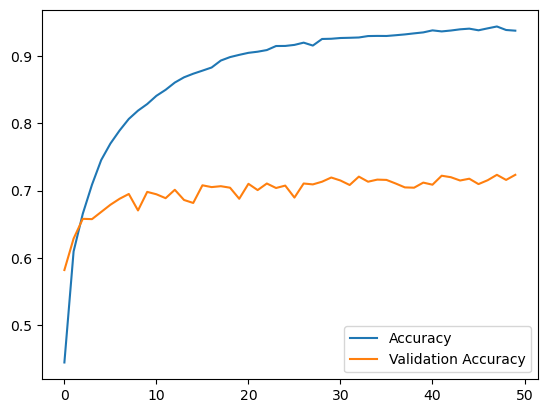

In [125]:
# comparação da acurácia e da validação ao longo do treinamento
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.legend()